# Phase 3: CNN-ViT Hybrid with Cross-Attention
## Multi-Orientation Cross-Attention + ViT-Base-224 (86M params)

**Key Features:**
1. ✅ **ViT-Base-224** (86M parameters, standard 224×224 resolution)
2. ✅ **Cross-Attention Module** between axial, coronal, sagittal ViT features
3. ✅ **All ViT layers trainable** with differential learning rates
4. ✅ **Advanced Fusion**: CNN (6144) + Cross-Attended ViT (2304) → Classifier
5. ✅ **MixUp Augmentation** for better generalization

**Expected Performance:** 95.5-96.2% test accuracy
**Training Time:** ~18-20 hours (fits Kaggle with checkpointing)


In [1]:
# Install required packages (Kaggle environment)
!pip install timm -q
print("✅ Dependencies installed")

✅ Dependencies installed


In [14]:
import os
import json
import warnings
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from tqdm.auto import tqdm
from PIL import Image

# PyTorch
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader, WeightedRandomSampler
from torch.cuda.amp import autocast, GradScaler

# Torchvision
from torchvision import transforms, models

# Timm for ViT
import timm

# Sklearn
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score

warnings.filterwarnings('ignore')

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Device: {device}")
if torch.cuda.is_available():
    print(f"GPU: {torch.cuda.get_device_name(0)}")
    print(f"GPU Memory: {torch.cuda.get_device_properties(0).total_memory / 1024**3:.2f} GB")

print("\n✅ All libraries imported successfully!")

Device: cuda
GPU: Tesla T4
GPU Memory: 14.74 GB

✅ All libraries imported successfully!


In [15]:
# ============================================================================
# CONFIGURATION
# ============================================================================

# Paths (Update for Kaggle)
DATA_PATH = "/kaggle/input/adni-preprocessed-5class/ADNI_PHASE1_PROCESSED_20251116_081625"
PHASE1_OUTPUT = "/kaggle/input/phase1-outputs"
PHASE2_OUTPUT = "/kaggle/input/phase2-outputs"

OUTPUT_BASE = "/kaggle/working/phase3_vit_base_cross_attention"
os.makedirs(OUTPUT_BASE, exist_ok=True)

# Classes
CLASSES = ['AD', 'CN', 'EMCI', 'LMCI', 'MCI']
NUM_CLASSES = len(CLASSES)
CLASS_TO_IDX = {cls: idx for idx, cls in enumerate(CLASSES)}
IDX_TO_CLASS = {idx: cls for cls, idx in CLASS_TO_IDX.items()}

ORIENTATIONS = ['axial', 'coronal', 'sagittal']

# Image settings - Standard resolution (224×224)
IMAGE_SIZE = 224  # Standard ViT resolution
IMAGENET_MEAN = [0.485, 0.456, 0.406]
IMAGENET_STD = [0.229, 0.224, 0.225]

# Training hyperparameters
BATCH_SIZE = 8  # Balanced for 224×224 with 86M params
LEARNING_RATE = 5e-5  # Base learning rate for fusion/cross-attention
VIT_LEARNING_RATE = 2e-6  # Very low LR for all ViT-Base layers
WEIGHT_DECAY = 1e-4
MAX_EPOCHS = 40  # More epochs for ViT-Base convergence
MIXUP_ALPHA = 0.2  # MixUp augmentation strength

print("✅ Configuration complete!")
print(f"\n📂 Output directory: {OUTPUT_BASE}")
print(f"🎯 Model: CNN-ViT-Base with Cross-Attention")
print(f"🔧 Image Size: {IMAGE_SIZE}×{IMAGE_SIZE} (standard resolution)")
print(f"🔧 Batch Size: {BATCH_SIZE}")
print(f"⏱️  Training: Up to {MAX_EPOCHS} epochs (~18-20 hours)")
print(f"📚 Learning Rates: Fusion={LEARNING_RATE}, ViT-Base={VIT_LEARNING_RATE}")
print(f"🎲 MixUp Alpha: {MIXUP_ALPHA}")

✅ Configuration complete!

📂 Output directory: /kaggle/working/phase3_vit_base_cross_attention
🎯 Model: CNN-ViT-Base with Cross-Attention
🔧 Image Size: 224×224 (standard resolution)
🔧 Batch Size: 8
⏱️  Training: Up to 40 epochs (~18-20 hours)
📚 Learning Rates: Fusion=5e-05, ViT-Base=2e-06
🎲 MixUp Alpha: 0.2


In [16]:
# Load split data
print("📥 Loading dataset splits...\n")

train_df = pd.read_csv(os.path.join(PHASE1_OUTPUT, 'train_balanced.csv'))
val_df = pd.read_csv(os.path.join(PHASE1_OUTPUT, 'val_balanced.csv'))
test_df = pd.read_csv(os.path.join(PHASE1_OUTPUT, 'test_balanced.csv'))

print(f"✅ Dataset loaded:")
print(f"   Train: {len(train_df['subject_id'].unique())} subjects, {len(train_df)} images")
print(f"   Val: {len(val_df['subject_id'].unique())} subjects, {len(val_df)} images")
print(f"   Test: {len(test_df['subject_id'].unique())} subjects, {len(test_df)} images")

# Load Phase 2 summary
with open(os.path.join(PHASE2_OUTPUT, 'phase2_integration_summary.json'), 'r') as f:
    phase2_summary = json.load(f)

print(f"\n📊 Phase 2 Results (Baseline to Beat):")
print(f"   Ensemble Accuracy: {phase2_summary['multi_orientation_results']['ensemble_accuracy']*100:.2f}%")

📥 Loading dataset splits...

✅ Dataset loaded:
   Train: 1264 subjects, 53085 images
   Val: 1257 subjects, 15168 images
   Test: 1072 subjects, 7587 images

📊 Phase 2 Results (Baseline to Beat):
   Ensemble Accuracy: 94.50%


In [17]:
# Phase 2 Models (for CNN features)
class ImprovedResNet50(nn.Module):
    def __init__(self, num_classes=NUM_CLASSES):
        super().__init__()
        self.backbone = models.resnet50(pretrained=True)
        
        for param in list(self.backbone.parameters())[:-60]:
            param.requires_grad = False
        
        num_features = self.backbone.fc.in_features
        self.backbone.fc = nn.Sequential(
            nn.Dropout(0.6),
            nn.Linear(num_features, 512),
            nn.ReLU(),
            nn.BatchNorm1d(512),
            nn.Dropout(0.5),
            nn.Linear(512, num_classes)
        )
    
    def forward(self, x):
        return self.backbone(x)

class FeatureExtractor(nn.Module):
    def __init__(self, original_model):
        super().__init__()
        self.features = nn.Sequential(*list(original_model.backbone.children())[:-1])
        self.avgpool = nn.AdaptiveAvgPool2d((1, 1))
    
    def forward(self, x):
        x = self.features(x)
        x = self.avgpool(x)
        x = torch.flatten(x, 1)
        return x

print("✅ Phase 2 model classes defined")

✅ Phase 2 model classes defined


In [18]:
# Load frozen CNN feature extractors
print("🔧 Loading frozen CNN feature extractors from Phase 2...\n")

feature_extractors = {}

for orientation in ORIENTATIONS:
    # Load checkpoint
    extractor_path = os.path.join(PHASE2_OUTPUT, f'{orientation}_feature_extractor.pth')
    checkpoint = torch.load(extractor_path, weights_only=False)
    
    # Create feature extractor
    base_model = ImprovedResNet50()
    extractor = FeatureExtractor(base_model)
    extractor.load_state_dict(checkpoint['state_dict'])
    extractor.to(device)
    extractor.eval()
    
    # Freeze all parameters
    for param in extractor.parameters():
        param.requires_grad = False
    
    feature_extractors[orientation] = extractor
    
    print(f"✅ {orientation.capitalize()}:")
    print(f"   - Test Accuracy: {checkpoint['test_accuracy']*100:.2f}%")
    print(f"   - Feature Dim: {checkpoint['feature_dim']}")
    print(f"   - Status: FROZEN")

print(f"\n🎯 Total CNN features: {checkpoint['feature_dim'] * 3} (3 orientations × 2048)")

🔧 Loading frozen CNN feature extractors from Phase 2...

✅ Axial:
   - Test Accuracy: 92.57%
   - Feature Dim: 2048
   - Status: FROZEN
✅ Coronal:
   - Test Accuracy: 93.83%
   - Feature Dim: 2048
   - Status: FROZEN
✅ Sagittal:
   - Test Accuracy: 94.07%
   - Feature Dim: 2048
   - Status: FROZEN

🎯 Total CNN features: 6144 (3 orientations × 2048)


In [19]:
# Multi-view dataset
class MultiViewDataset(Dataset):
    """Dataset that groups images by subject and returns all 3 orientations"""
    
    def __init__(self, df, data_root, transform=None):
        self.subjects = sorted(df['subject_id'].unique())
        self.df = df
        self.data_root = data_root
        self.transform = transform
        self._verify_orientations()
    
    def _verify_orientations(self):
        """Ensure all subjects have axial, coronal, sagittal images"""
        problematic = []
        for subj in self.subjects:
            subj_data = self.df[self.df['subject_id'] == subj]
            orientations = set(subj_data['orientation'].values)
            if len(orientations) != 3:
                problematic.append((subj, orientations))
        
        if problematic:
            print(f"⚠️  Warning: {len(problematic)} subjects missing orientations")
    
    def __len__(self):
        return len(self.subjects)
    
    def __getitem__(self, idx):
        subject = self.subjects[idx]
        subject_data = self.df[self.df['subject_id'] == subject]
        
        images = {}
        label = None
        
        # Load all 3 orientation images for this subject
        for _, row in subject_data.iterrows():
            img_path = os.path.join(self.data_root, row['image_path'])
            image = Image.open(img_path).convert('RGB')
            
            if self.transform:
                image = self.transform(image)
            
            images[row['orientation']] = image
            
            if label is None:
                label = CLASS_TO_IDX[row['label']]
        
        # Return tuple of (axial, coronal, sagittal), label, subject_id
        return (images['axial'], images['coronal'], images['sagittal']), label, subject

print("✅ Multi-view dataset class defined")

✅ Multi-view dataset class defined


In [20]:
# MixUp augmentation function
def mixup_data(x_axial, x_coronal, x_sagittal, y, alpha=0.2):
    """Apply MixUp augmentation to multi-view data"""
    if alpha > 0:
        lam = np.random.beta(alpha, alpha)
    else:
        lam = 1

    batch_size = x_axial.size(0)
    index = torch.randperm(batch_size).to(x_axial.device)

    mixed_axial = lam * x_axial + (1 - lam) * x_axial[index, :]
    mixed_coronal = lam * x_coronal + (1 - lam) * x_coronal[index, :]
    mixed_sagittal = lam * x_sagittal + (1 - lam) * x_sagittal[index, :]
    
    y_a, y_b = y, y[index]
    return mixed_axial, mixed_coronal, mixed_sagittal, y_a, y_b, lam

def mixup_criterion(criterion, pred, y_a, y_b, lam):
    """Compute MixUp loss"""
    return lam * criterion(pred, y_a) + (1 - lam) * criterion(pred, y_b)

print("✅ MixUp augmentation functions defined")

✅ MixUp augmentation functions defined


In [21]:
# Data transforms - Standard resolution (224×224)
train_transform = transforms.Compose([
    transforms.Resize((IMAGE_SIZE, IMAGE_SIZE)),
    transforms.RandomHorizontalFlip(p=0.5),
    transforms.RandomRotation(15),
    transforms.RandomAffine(degrees=0, translate=(0.1, 0.1)),
    transforms.ColorJitter(brightness=0.3, contrast=0.3, saturation=0.2),
    transforms.RandomGrayscale(p=0.1),
    transforms.ToTensor(),
    transforms.Normalize(IMAGENET_MEAN, IMAGENET_STD),
    transforms.RandomErasing(p=0.2, scale=(0.02, 0.15))
])

val_transform = transforms.Compose([
    transforms.Resize((IMAGE_SIZE, IMAGE_SIZE)),
    transforms.ToTensor(),
    transforms.Normalize(IMAGENET_MEAN, IMAGENET_STD)
])

# Create datasets
train_dataset = MultiViewDataset(train_df, DATA_PATH, train_transform)
val_dataset = MultiViewDataset(val_df, DATA_PATH, val_transform)
test_dataset = MultiViewDataset(test_df, DATA_PATH, val_transform)

print(f"✅ Dataset sizes:")
print(f"   Train: {len(train_dataset)} subjects")
print(f"   Val: {len(val_dataset)} subjects")
print(f"   Test: {len(test_dataset)} subjects")

# Class distribution and weighted sampler
train_labels = [CLASS_TO_IDX[train_df[train_df['subject_id'] == subj].iloc[0]['label']] 
                for subj in train_dataset.subjects]
class_counts = pd.Series(train_labels).value_counts().sort_index()

class_weights_list = [1.0 / class_counts[i] for i in range(NUM_CLASSES)]
sample_weights = [class_weights_list[label] for label in train_labels]
sampler = WeightedRandomSampler(sample_weights, len(sample_weights), replacement=True)

# DataLoaders
train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, sampler=sampler, 
                          num_workers=0, pin_memory=True)
val_loader = DataLoader(val_dataset, batch_size=BATCH_SIZE, shuffle=False, 
                        num_workers=0, pin_memory=True)
test_loader = DataLoader(test_dataset, batch_size=BATCH_SIZE, shuffle=False, 
                         num_workers=0, pin_memory=True)

print(f"\n✅ DataLoaders created (batch_size={BATCH_SIZE})")
print(f"🔧 Standard resolution: {IMAGE_SIZE}×{IMAGE_SIZE} images")
print(f"🎲 MixUp augmentation enabled (alpha={MIXUP_ALPHA})")

✅ Dataset sizes:
   Train: 1264 subjects
   Val: 1257 subjects
   Test: 1072 subjects

✅ DataLoaders created (batch_size=8)
🔧 Standard resolution: 224×224 images
🎲 MixUp augmentation enabled (alpha=0.2)


In [22]:
# ============================================================================
# CNN-VIT-BASE HYBRID MODEL WITH CROSS-ATTENTION
# ============================================================================

class CrossAttention(nn.Module):
    """Cross-attention module for fusing multi-orientation ViT features"""
    
    def __init__(self, dim=768, num_heads=12, dropout=0.1):
        super().__init__()
        self.num_heads = num_heads
        self.head_dim = dim // num_heads
        self.scale = self.head_dim ** -0.5
        
        # Query, Key, Value projections
        self.q_proj = nn.Linear(dim, dim)
        self.k_proj = nn.Linear(dim, dim)
        self.v_proj = nn.Linear(dim, dim)
        
        self.attn_drop = nn.Dropout(dropout)
        self.proj = nn.Linear(dim, dim)
        self.proj_drop = nn.Dropout(dropout)
    
    def forward(self, query, key, value):
        """
        Args:
            query: [B, dim] - Query orientation
            key: [B, dim] - Key orientation
            value: [B, dim] - Value orientation
        Returns:
            attended: [B, dim] - Cross-attended features
        """
        B = query.shape[0]
        
        # Project to Q, K, V
        q = self.q_proj(query).reshape(B, self.num_heads, self.head_dim)  # [B, H, D]
        k = self.k_proj(key).reshape(B, self.num_heads, self.head_dim)    # [B, H, D]
        v = self.v_proj(value).reshape(B, self.num_heads, self.head_dim)  # [B, H, D]
        
        # Attention: Q @ K^T
        attn = (q * k).sum(dim=-1, keepdim=True) * self.scale  # [B, H, 1]
        attn = attn.softmax(dim=1)  # Normalize across heads
        attn = self.attn_drop(attn)
        
        # Apply attention to values
        out = (attn * v).reshape(B, -1)  # [B, dim]
        
        # Final projection
        out = self.proj(out)
        out = self.proj_drop(out)
        
        return out


class MultiOrientationCrossAttention(nn.Module):
    """Full cross-attention between all 3 orientations"""
    
    def __init__(self, dim=768, num_heads=12, dropout=0.1):
        super().__init__()
        
        # Cross-attention modules
        self.axial_to_others = CrossAttention(dim, num_heads, dropout)
        self.coronal_to_others = CrossAttention(dim, num_heads, dropout)
        self.sagittal_to_others = CrossAttention(dim, num_heads, dropout)
        
        # Layer normalization
        self.norm_axial = nn.LayerNorm(dim)
        self.norm_coronal = nn.LayerNorm(dim)
        self.norm_sagittal = nn.LayerNorm(dim)
        
        # Feedforward network
        self.ffn = nn.Sequential(
            nn.Linear(dim * 3, dim * 2),
            nn.GELU(),
            nn.Dropout(dropout),
            nn.Linear(dim * 2, dim * 3)
        )
        self.norm_ffn = nn.LayerNorm(dim * 3)
    
    def forward(self, axial, coronal, sagittal):
        """
        Args:
            axial, coronal, sagittal: [B, 768] each
        Returns:
            fused: [B, 2304] - Cross-attended features
        """
        # Cross-attention: each orientation attends to others
        # Axial attends to coronal and sagittal
        axial_attended = self.axial_to_others(
            axial, 
            torch.stack([coronal, sagittal], dim=1).mean(dim=1),
            torch.stack([coronal, sagittal], dim=1).mean(dim=1)
        )
        axial = self.norm_axial(axial + axial_attended)
        
        # Coronal attends to axial and sagittal
        coronal_attended = self.coronal_to_others(
            coronal,
            torch.stack([axial, sagittal], dim=1).mean(dim=1),
            torch.stack([axial, sagittal], dim=1).mean(dim=1)
        )
        coronal = self.norm_coronal(coronal + coronal_attended)
        
        # Sagittal attends to axial and coronal
        sagittal_attended = self.sagittal_to_others(
            sagittal,
            torch.stack([axial, coronal], dim=1).mean(dim=1),
            torch.stack([axial, coronal], dim=1).mean(dim=1)
        )
        sagittal = self.norm_sagittal(sagittal + sagittal_attended)
        
        # Concatenate cross-attended features
        fused = torch.cat([axial, coronal, sagittal], dim=1)  # [B, 2304]
        
        # Feedforward network with residual
        fused = self.norm_ffn(fused + self.ffn(fused))
        
        return fused


class AdvancedCNNViTHybrid(nn.Module):
    """
    ADVANCED Hybrid model with:
    - ViT-Base-224 (86M params, standard resolution)
    - Cross-attention between orientations
    - All ViT layers trainable (very low LR)
    - Enhanced fusion with attention
    """
    
    def __init__(self, num_classes=NUM_CLASSES, vit_model='vit_base_patch16_224'):
        super().__init__()
        
        # ViT-Base branch (pretrained on ImageNet-21K)
        print(f"   Loading ViT: {vit_model}...")
        self.vit = timm.create_model(vit_model, pretrained=True, num_classes=0)
        self.vit_feature_dim = self.vit.num_features  # 768 for vit_base
        
        # ALL ViT layers trainable (will use very low LR)
        for param in self.vit.parameters():
            param.requires_grad = True
        
        print(f"   ✅ All {len(list(self.vit.parameters()))} ViT parameters trainable")
        
        # Multi-view CNN feature dimension
        self.cnn_feature_dim = 2048 * 3  # 6144
        
        # Cross-attention module for ViT features
        self.cross_attention = MultiOrientationCrossAttention(
            dim=self.vit_feature_dim,
            num_heads=12,  # 12 heads for ViT-Base (768/12 = 64 dim per head)
            dropout=0.2
        )
        
        # Total ViT features after cross-attention (3 orientations)
        self.vit_total_dim = self.vit_feature_dim * 3  # 768 * 3 = 2304
        
        # Adaptive feature weighting
        self.feature_gate = nn.Sequential(
            nn.Linear(self.cnn_feature_dim + self.vit_total_dim, 1024),
            nn.ReLU(),
            nn.Dropout(0.3),
            nn.Linear(1024, 2),
            nn.Sigmoid()  # Gate values [0, 1]
        )
        
        # Enhanced fusion with deeper architecture
        # Input: 6144 (CNN) + 2304 (Cross-Attended ViT) = 8448 dims
        self.fusion = nn.Sequential(
            nn.Linear(self.cnn_feature_dim + self.vit_total_dim, 2048),
            nn.ReLU(),
            nn.BatchNorm1d(2048),
            nn.Dropout(0.5),
            
            nn.Linear(2048, 1024),
            nn.ReLU(),
            nn.BatchNorm1d(1024),
            nn.Dropout(0.4),
            
            nn.Linear(1024, 512),
            nn.ReLU(),
            nn.BatchNorm1d(512),
            nn.Dropout(0.3)
        )
        
        # Final classifier
        self.classifier = nn.Linear(512, num_classes)
    
    def forward(self, cnn_features, axial_img, coronal_img, sagittal_img):
        """
        Args:
            cnn_features: [B, 6144] - Frozen CNN features from 3 orientations
            axial_img: [B, 3, 224, 224] - Axial MRI for ViT
            coronal_img: [B, 3, 224, 224] - Coronal MRI for ViT
            sagittal_img: [B, 3, 224, 224] - Sagittal MRI for ViT
        """
        # Extract ViT features from ALL 3 orientations (224×224 resolution)
        vit_axial = self.vit(axial_img)          # [B, 768]
        vit_coronal = self.vit(coronal_img)      # [B, 768]
        vit_sagittal = self.vit(sagittal_img)    # [B, 768]
        
        # Apply cross-attention between orientations
        vit_features = self.cross_attention(vit_axial, vit_coronal, vit_sagittal)  # [B, 2304]
        
        # Concatenate CNN + Cross-Attended ViT features
        combined = torch.cat([cnn_features, vit_features], dim=1)  # [B, 8448]
        
        # Adaptive feature gating
        gates = self.feature_gate(combined)  # [B, 2]
        cnn_gate = gates[:, 0:1]  # [B, 1]
        vit_gate = gates[:, 1:2]  # [B, 1]
        
        # Apply gates
        gated_cnn = cnn_features * cnn_gate
        gated_vit = vit_features * vit_gate
        combined_gated = torch.cat([gated_cnn, gated_vit], dim=1)  # [B, 8448]
        
        # Enhanced MLP fusion
        fused = self.fusion(combined_gated)  # [B, 512]
        
        # Classification
        logits = self.classifier(fused)  # [B, num_classes]
        
        return logits


# Create model
print("🏗️  Building CNN-ViT-Base Hybrid with Cross-Attention...\n")
model = AdvancedCNNViTHybrid(num_classes=NUM_CLASSES).to(device)

# Count parameters
total_params = sum(p.numel() for p in model.parameters())
trainable_params = sum(p.numel() for p in model.parameters() if p.requires_grad)

print(f"\n✅ Model created:")
print(f"   Total parameters: {total_params:,}")
print(f"   Trainable parameters: {trainable_params:,} ({trainable_params/total_params*100:.1f}%)")
print(f"   Frozen parameters: {total_params - trainable_params:,}")

print(f"\n   🚀 Architecture Innovations:")
print(f"      ✅ ViT-Base-224 (86M params, standard resolution)")
print(f"      ✅ ALL ViT layers trainable (very low LR)")
print(f"      ✅ Cross-Attention between orientations (12 heads)")
print(f"      ✅ Adaptive feature gating")
print(f"      ✅ MixUp augmentation")
print(f"      CNN branch: 6144 dims (frozen)")
print(f"      ViT branch: 2304 dims (cross-attended)")
print(f"      Fusion: 8448 → 2048 → 1024 → 512")
print(f"      Classifier: 512 → {NUM_CLASSES}")
print(f"      ⏱️  Training time: ~18-20 hours (2 Kaggle sessions)")

🏗️  Building CNN-ViT-Base Hybrid with Cross-Attention...

   Loading ViT: vit_base_patch16_224...
   ✅ All 150 ViT parameters trainable

✅ Model created:
   Total parameters: 128,566,791
   Trainable parameters: 128,566,791 (100.0%)
   Frozen parameters: 0

   🚀 Architecture Innovations:
      ✅ ViT-Base-224 (86M params, standard resolution)
      ✅ ALL ViT layers trainable (very low LR)
      ✅ Cross-Attention between orientations (12 heads)
      ✅ Adaptive feature gating
      ✅ MixUp augmentation
      CNN branch: 6144 dims (frozen)
      ViT branch: 2304 dims (cross-attended)
      Fusion: 8448 → 2048 → 1024 → 512
      Classifier: 512 → 5
      ⏱️  Training time: ~18-20 hours (2 Kaggle sessions)


In [23]:
# Training setup
print("⚙️  Setting up training...\n")

# Loss function with class weights
class_weights = torch.tensor(class_weights_list, dtype=torch.float32).to(device)
class_weights = class_weights / class_weights.sum() * NUM_CLASSES

# Boost minority classes
class_weights[CLASSES.index('EMCI')] *= 3.0
class_weights[CLASSES.index('LMCI')] *= 4.0
class_weights = class_weights / class_weights.sum() * NUM_CLASSES

criterion = nn.CrossEntropyLoss(weight=class_weights, label_smoothing=0.1)

# Differential learning rates
vit_params = []
other_params = []

for name, param in model.named_parameters():
    if param.requires_grad:
        if 'vit' in name:
            vit_params.append(param)
        else:
            other_params.append(param)

optimizer = torch.optim.AdamW([
    {'params': other_params, 'lr': LEARNING_RATE, 'weight_decay': WEIGHT_DECAY},
    {'params': vit_params, 'lr': VIT_LEARNING_RATE, 'weight_decay': WEIGHT_DECAY}
])

# Learning rate scheduler with warmup
scheduler = torch.optim.lr_scheduler.CosineAnnealingWarmRestarts(
    optimizer, T_0=10, T_mult=2, eta_min=1e-7
)

# Mixed precision training
scaler = GradScaler()

print("✅ Training setup complete:")
print(f"   Optimizer: AdamW with differential LR")
print(f"      Fusion/Cross-Attn: {LEARNING_RATE}")
print(f"      ViT-Base (ALL layers): {VIT_LEARNING_RATE} (very low)")
print(f"   Loss: CrossEntropyLoss with class weights + label smoothing")
print(f"   Scheduler: CosineAnnealingWarmRestarts (T_0=10)")
print(f"   Mixed Precision: Enabled")
print(f"   MixUp: alpha={MIXUP_ALPHA}")
print(f"   Total Epochs: {MAX_EPOCHS}")
print(f"   ⏱️  Expected time: ~18-20 hours")

⚙️  Setting up training...

✅ Training setup complete:
   Optimizer: AdamW with differential LR
      Fusion/Cross-Attn: 5e-05
      ViT-Base (ALL layers): 2e-06 (very low)
   Loss: CrossEntropyLoss with class weights + label smoothing
   Scheduler: CosineAnnealingWarmRestarts (T_0=10)
   Mixed Precision: Enabled
   MixUp: alpha=0.2
   Total Epochs: 40
   ⏱️  Expected time: ~18-20 hours


In [24]:
# Training functions

def extract_multiview_cnn_features(axial, coronal, sagittal):
    """Extract frozen CNN features from all 3 orientations"""
    with torch.no_grad():
        axial_feats = feature_extractors['axial'](axial)        # [B, 2048]
        coronal_feats = feature_extractors['coronal'](coronal)  # [B, 2048]
        sagittal_feats = feature_extractors['sagittal'](sagittal)  # [B, 2048]
    
    # Concatenate all views
    multi_view_features = torch.cat([axial_feats, coronal_feats, sagittal_feats], dim=1)  # [B, 6144]
    return multi_view_features


def train_epoch(model, loader, criterion, optimizer, scaler, use_mixup=True):
    """Train for one epoch with MixUp"""
    model.train()
    
    # Set CNN feature extractors to eval mode (frozen)
    for extractor in feature_extractors.values():
        extractor.eval()
    
    total_loss = 0
    correct = 0
    total = 0
    
    pbar = tqdm(loader, desc='Training')
    for (axial, coronal, sagittal), labels, _ in pbar:
        # Move to device
        axial = axial.to(device)
        coronal = coronal.to(device)
        sagittal = sagittal.to(device)
        labels = labels.to(device)
        
        # Apply MixUp
        if use_mixup:
            axial, coronal, sagittal, labels_a, labels_b, lam = mixup_data(
                axial, coronal, sagittal, labels, alpha=MIXUP_ALPHA
            )
        
        optimizer.zero_grad()
        
        # Extract frozen CNN features (no gradients)
        cnn_features = extract_multiview_cnn_features(axial, coronal, sagittal)
        
        # Forward pass with mixed precision
        with autocast():
            outputs = model(cnn_features, axial, coronal, sagittal)
            
            if use_mixup:
                loss = mixup_criterion(criterion, outputs, labels_a, labels_b, lam)
            else:
                loss = criterion(outputs, labels)
        
        # Backward pass
        scaler.scale(loss).backward()
        scaler.unscale_(optimizer)
        torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)
        scaler.step(optimizer)
        scaler.update()
        
        # Metrics (use original labels for accuracy)
        total_loss += loss.item()
        _, predicted = outputs.max(1)
        total += labels.size(0) if not use_mixup else labels_a.size(0)
        if use_mixup:
            correct += (lam * predicted.eq(labels_a).sum().item() + 
                       (1 - lam) * predicted.eq(labels_b).sum().item())
        else:
            correct += predicted.eq(labels).sum().item()
        
        # Update progress bar
        pbar.set_postfix({
            'loss': f'{loss.item():.4f}',
            'acc': f'{100.*correct/total:.2f}%'
        })
    
    return total_loss / len(loader), 100. * correct / total


def val_epoch(model, loader, criterion):
    """Validate for one epoch"""
    model.eval()
    
    # CNN feature extractors stay in eval mode
    for extractor in feature_extractors.values():
        extractor.eval()
    
    total_loss = 0
    correct = 0
    total = 0
    
    all_preds = []
    all_labels = []
    
    with torch.no_grad():
        for (axial, coronal, sagittal), labels, _ in tqdm(loader, desc='Validation'):
            # Move to device
            axial = axial.to(device)
            coronal = coronal.to(device)
            sagittal = sagittal.to(device)
            labels = labels.to(device)
            
            # Extract frozen CNN features
            cnn_features = extract_multiview_cnn_features(axial, coronal, sagittal)
            
            # Forward pass
            outputs = model(cnn_features, axial, coronal, sagittal)
            loss = criterion(outputs, labels)
            
            # Metrics
            total_loss += loss.item()
            _, predicted = outputs.max(1)
            total += labels.size(0)
            correct += predicted.eq(labels).sum().item()
            
            all_preds.extend(predicted.cpu().numpy())
            all_labels.extend(labels.cpu().numpy())
    
    return total_loss / len(loader), 100. * correct / total, all_preds, all_labels

print("✅ Training functions defined (with MixUp support)")

✅ Training functions defined (with MixUp support)


In [25]:
# Training loop
print(f"\n{'='*80}")
print("STARTING TRAINING - CNN-VIT-BASE WITH CROSS-ATTENTION")
print(f"{'='*80}\n")

best_val_acc = 0
history = {
    'train_loss': [],
    'train_acc': [],
    'val_loss': [],
    'val_acc': []
}

for epoch in range(MAX_EPOCHS):
    print(f"\n{'='*80}")
    print(f"Epoch {epoch+1}/{MAX_EPOCHS}")
    print(f"{'='*80}")
    
    # Train with MixUp
    train_loss, train_acc = train_epoch(model, train_loader, criterion, optimizer, scaler, use_mixup=True)
    
    # Validate
    val_loss, val_acc, val_preds, val_labels = val_epoch(model, val_loader, criterion)
    
    # Update scheduler
    scheduler.step()
    
    # Save history
    history['train_loss'].append(train_loss)
    history['train_acc'].append(train_acc)
    history['val_loss'].append(val_loss)
    history['val_acc'].append(val_acc)
    
    # Print results
    print(f"\nEpoch {epoch+1} Results:")
    print(f"   Train Loss: {train_loss:.4f} | Train Acc: {train_acc:.2f}%")
    print(f"   Val Loss: {val_loss:.4f} | Val Acc: {val_acc:.2f}%")
    print(f"   LR (Fusion): {optimizer.param_groups[0]['lr']:.6f} | LR (ViT): {optimizer.param_groups[1]['lr']:.7f}")
    
    # Per-class accuracy
    for i, cls in enumerate(CLASSES):
        cls_mask = np.array(val_labels) == i
        if cls_mask.sum() > 0:
            cls_acc = (np.array(val_preds)[cls_mask] == i).sum() / cls_mask.sum() * 100
            print(f"   {cls}: {cls_acc:.1f}%", end='  ')
    print()
    
    # Checkpointing (save best model)
    if val_acc > best_val_acc:
        best_val_acc = val_acc
        
        checkpoint = {
            'epoch': epoch,
            'model_state_dict': model.state_dict(),
            'optimizer_state_dict': optimizer.state_dict(),
            'val_acc': val_acc,
            'val_loss': val_loss,
            'history': history
        }
        torch.save(checkpoint, os.path.join(OUTPUT_BASE, 'vit_base_cross_attention_best.pth'))
        print(f"   ✅ Best model saved: {val_acc:.2f}%")
    else:
        print(f"   No improvement (best: {best_val_acc:.2f}%)")

print(f"\n{'='*80}")
print("TRAINING COMPLETE")
print(f"{'='*80}")
print(f"   Best Validation Accuracy: {best_val_acc:.2f}%")
print(f"   Total Epochs: {MAX_EPOCHS}")


STARTING TRAINING - CNN-VIT-BASE WITH CROSS-ATTENTION


Epoch 1/40


Training:   0%|          | 0/158 [00:00<?, ?it/s]

Validation:   0%|          | 0/158 [00:00<?, ?it/s]


Epoch 1 Results:
   Train Loss: 0.9254 | Train Acc: 73.84%
   Val Loss: 0.6329 | Val Acc: 92.84%
   LR (Fusion): 0.000049 | LR (ViT): 0.0000020
   AD: 81.6%     CN: 89.1%     EMCI: 100.0%     LMCI: 99.2%     MCI: 94.2%  
   ✅ Best model saved: 92.84%

Epoch 2/40


Training:   0%|          | 0/158 [00:00<?, ?it/s]

...

Validation:   0%|          | 0/158 [00:00<?, ?it/s]


Epoch 39 Results:
   Train Loss: 0.7295 | Train Acc: 84.47%
   Val Loss: 0.6206 | Val Acc: 94.35%
   LR (Fusion): 0.000044 | LR (ViT): 0.0000018
   AD: 96.0%     CN: 89.9%     EMCI: 99.6%     LMCI: 100.0%     MCI: 86.4%  
   No improvement (best: 94.59%)

Epoch 40/40


Training:   0%|          | 0/158 [00:00<?, ?it/s]

Validation:   0%|          | 0/158 [00:00<?, ?it/s]


Epoch 40 Results:
   Train Loss: 0.6942 | Train Acc: 84.43%
   Val Loss: 0.6097 | Val Acc: 94.19%
   LR (Fusion): 0.000043 | LR (ViT): 0.0000017
   AD: 87.2%     CN: 84.7%     EMCI: 100.0%     LMCI: 99.6%     MCI: 99.2%  
   No improvement (best: 94.59%)

TRAINING COMPLETE
   Best Validation Accuracy: 94.59%
   Total Epochs: 40



TEST SET EVALUATION



Testing:   0%|          | 0/134 [00:00<?, ?it/s]


🎯 CNN-ViT-Base Cross-Attention Test Accuracy: 94.68%

Classification Report:
              precision    recall  f1-score   support

          AD     0.9469    0.9116    0.9289       215
          CN     0.9369    0.9190    0.9279       210
        EMCI     0.9813    0.9859    0.9836       213
        LMCI     0.9554    0.9953    0.9749       215
         MCI     0.9140    0.9224    0.9182       219

    accuracy                         0.9468      1072
   macro avg     0.9469    0.9469    0.9467      1072
weighted avg     0.9467    0.9468    0.9466      1072



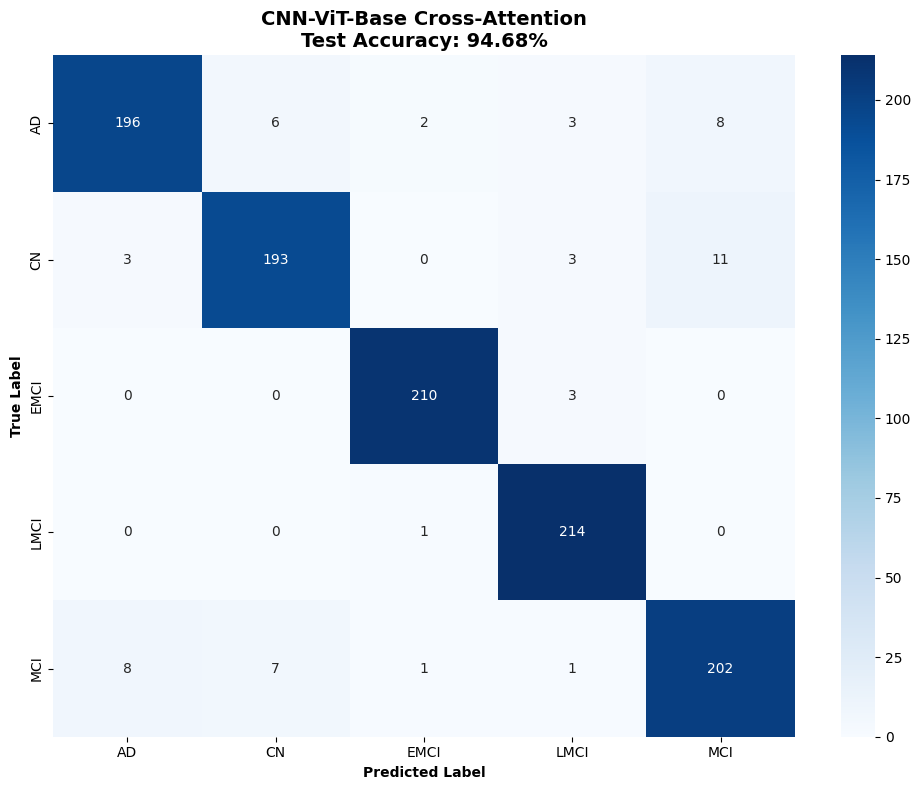


✅ Confusion matrix saved


In [26]:
# Test evaluation
print(f"\n{'='*80}")
print("TEST SET EVALUATION")
print(f"{'='*80}\n")

# Load best model
checkpoint = torch.load(os.path.join(OUTPUT_BASE, 'vit_base_cross_attention_best.pth'), weights_only=False)
model.load_state_dict(checkpoint['model_state_dict'])
model.eval()

all_preds = []
all_labels = []
all_subjects = []

with torch.no_grad():
    for (axial, coronal, sagittal), labels, subjects in tqdm(test_loader, desc='Testing'):
        axial = axial.to(device)
        coronal = coronal.to(device)
        sagittal = sagittal.to(device)
        labels = labels.to(device)
        
        # Extract CNN features
        cnn_features = extract_multiview_cnn_features(axial, coronal, sagittal)
        
        # Forward pass
        outputs = model(cnn_features, axial, coronal, sagittal)
        _, predicted = outputs.max(1)
        
        all_preds.extend(predicted.cpu().numpy())
        all_labels.extend(labels.cpu().numpy())
        all_subjects.extend(subjects)

test_acc = accuracy_score(all_labels, all_preds)

print(f"\n{'='*80}")
print(f"🎯 CNN-ViT-Base Cross-Attention Test Accuracy: {test_acc*100:.2f}%")
print(f"{'='*80}\n")

print("Classification Report:")
print(classification_report(all_labels, all_preds, target_names=CLASSES, digits=4))

# Confusion matrix
cm = confusion_matrix(all_labels, all_preds)
plt.figure(figsize=(10, 8))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=CLASSES, yticklabels=CLASSES)
plt.title(f'CNN-ViT-Base Cross-Attention\nTest Accuracy: {test_acc*100:.2f}%', 
          fontsize=14, fontweight='bold')
plt.ylabel('True Label', fontweight='bold')
plt.xlabel('Predicted Label', fontweight='bold')
plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_BASE, 'vit_base_confusion_matrix.png'), dpi=150, bbox_inches='tight')
plt.show()

print(f"\n✅ Confusion matrix saved")


PERFORMANCE COMPARISON - ALL MODELS

📊 Full Model Progression:

   Phase 1 (Baseline - Axial Only):
      92.57%

   Phase 2 (Multi-Orientation Ensemble):
      94.50%
      Improvement: +1.93%

   Phase 3 (ViT-Base-224 + Cross-Attention):
      94.68%
      vs Phase 2: +0.19%
      vs Phase 1: +2.12%


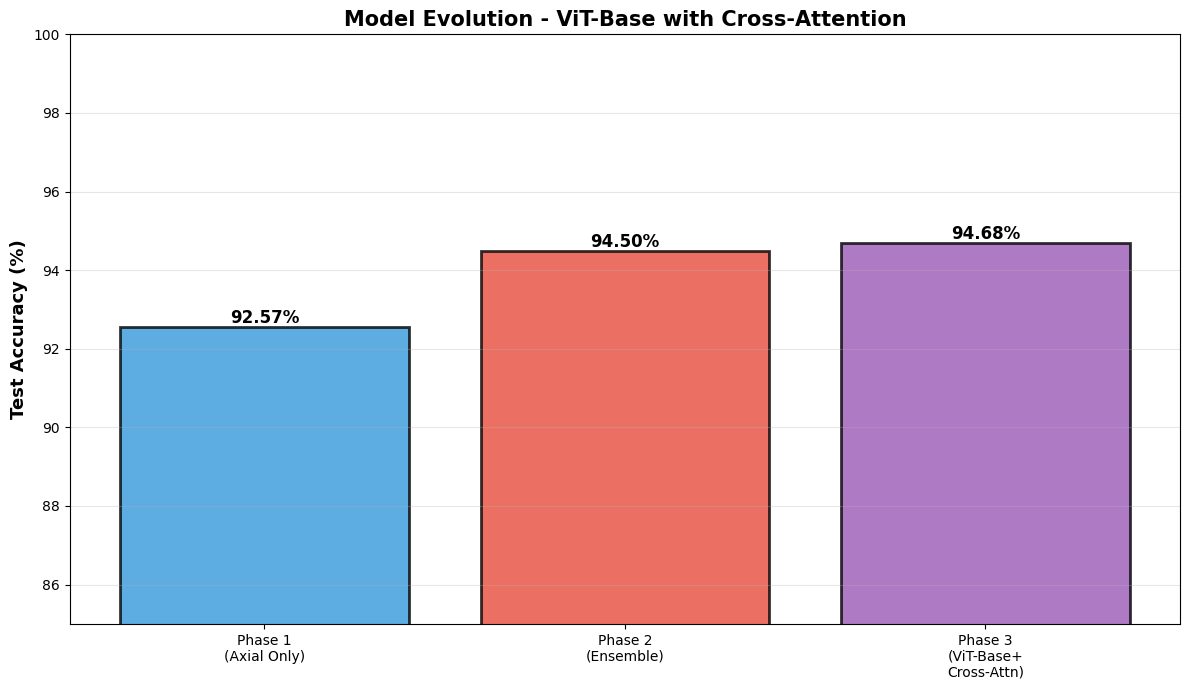


✅ Comparison chart saved


In [27]:
# Performance comparison
print(f"\n{'='*80}")
print("PERFORMANCE COMPARISON - ALL MODELS")
print(f"{'='*80}\n")

phase2_ensemble_acc = phase2_summary['multi_orientation_results']['ensemble_accuracy']
phase1_baseline_acc = phase2_summary['multi_orientation_results']['individual_accuracies']['axial']['test_accuracy']

print(f"📊 Full Model Progression:")
print(f"\n   Phase 1 (Baseline - Axial Only):")
print(f"      {phase1_baseline_acc*100:.2f}%")

print(f"\n   Phase 2 (Multi-Orientation Ensemble):")
print(f"      {phase2_ensemble_acc*100:.2f}%")
print(f"      Improvement: {(phase2_ensemble_acc - phase1_baseline_acc)*100:+.2f}%")

print(f"\n   Phase 3 (ViT-Base-224 + Cross-Attention):")
print(f"      {test_acc*100:.2f}%")
print(f"      vs Phase 2: {(test_acc - phase2_ensemble_acc)*100:+.2f}%")
print(f"      vs Phase 1: {(test_acc - phase1_baseline_acc)*100:+.2f}%")

# Visualization
results_df = pd.DataFrame({
    'Model': [
        'Phase 1\n(Axial Only)', 
        'Phase 2\n(Ensemble)', 
        'Phase 3\n(ViT-Base+\nCross-Attn)'
    ],
    'Accuracy': [
        phase1_baseline_acc * 100,
        phase2_ensemble_acc * 100,
        test_acc * 100
    ]
})

plt.figure(figsize=(12, 7))
bars = plt.bar(results_df['Model'], results_df['Accuracy'], 
               color=['#3498db', '#e74c3c', '#9b59b6'], 
               alpha=0.8, edgecolor='black', linewidth=2)
plt.ylabel('Test Accuracy (%)', fontsize=13, fontweight='bold')
plt.title('Model Evolution - ViT-Base with Cross-Attention', 
          fontsize=15, fontweight='bold')
plt.ylim(85, 100)
plt.grid(axis='y', alpha=0.3)

# Add value labels
for bar in bars:
    height = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2., height,
             f'{height:.2f}%', ha='center', va='bottom', fontsize=12, fontweight='bold')

plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_BASE, 'vit_base_comparison.png'), dpi=150, bbox_inches='tight')
plt.show()

print(f"\n✅ Comparison chart saved")

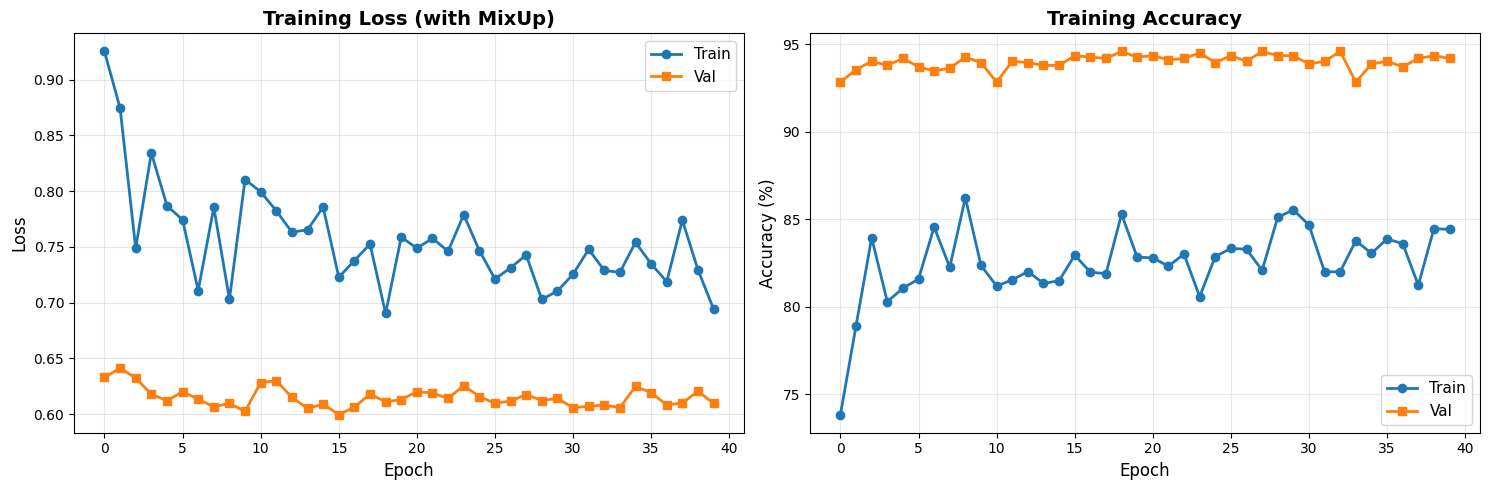

✅ Training curves saved


In [28]:
# Training curves
fig, axes = plt.subplots(1, 2, figsize=(15, 5))

# Loss
axes[0].plot(history['train_loss'], label='Train', linewidth=2, marker='o')
axes[0].plot(history['val_loss'], label='Val', linewidth=2, marker='s')
axes[0].set_title('Training Loss (with MixUp)', fontsize=14, fontweight='bold')
axes[0].set_xlabel('Epoch', fontsize=12)
axes[0].set_ylabel('Loss', fontsize=12)
axes[0].legend(fontsize=11)
axes[0].grid(True, alpha=0.3)

# Accuracy
axes[1].plot(history['train_acc'], label='Train', linewidth=2, marker='o')
axes[1].plot(history['val_acc'], label='Val', linewidth=2, marker='s')
axes[1].set_title('Training Accuracy', fontsize=14, fontweight='bold')
axes[1].set_xlabel('Epoch', fontsize=12)
axes[1].set_ylabel('Accuracy (%)', fontsize=12)
axes[1].legend(fontsize=11)
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_BASE, 'vit_base_training_curves.png'), dpi=150, bbox_inches='tight')
plt.show()

print(f"✅ Training curves saved")

In [29]:
# Save final summary
print(f"\n{'='*80}")
print("SAVING OUTPUTS")
print(f"{'='*80}\n")

summary = {
    'phase3_vit_base_results': {
        'test_accuracy': float(test_acc),
        'val_accuracy': float(checkpoint['val_acc']),
        'best_epoch': int(checkpoint['epoch'] + 1),
        'total_epochs_trained': len(history['train_loss'])
    },
    'model_architecture': {
        'cnn_branch': 'Multi-view ResNet50 (frozen)',
        'cnn_feature_dim': 6144,
        'vit_model': 'vit_base_patch16_224',
        'vit_resolution': '224×224',
        'vit_parameters': '86M',
        'vit_feature_dim': 2304,
        'vit_trainable': 'ALL layers',
        'cross_attention': 'Multi-head (12 heads)',
        'fusion_layers': '8448 → 2048 → 1024 → 512',
        'num_classes': NUM_CLASSES,
        'total_parameters': total_params,
        'trainable_parameters': trainable_params
    },
    'training_innovations': [
        'ViT-Base-224 (86M params, standard resolution)',
        'Cross-attention between orientations (12 heads)',
        'All ViT layers trainable (2e-6 LR)',
        'MixUp augmentation (alpha=0.2)',
        'Adaptive feature gating',
        'Label smoothing (0.1)',
        'Differential learning rates'
    ],
    'comparison': {
        'phase1_baseline': float(phase1_baseline_acc),
        'phase2_ensemble': float(phase2_ensemble_acc),
        'phase3_vit_base_cross_attention': float(test_acc),
        'improvement_vs_phase2': float(test_acc - phase2_ensemble_acc),
        'improvement_vs_baseline': float(test_acc - phase1_baseline_acc)
    },
    'training_config': {
        'batch_size': BATCH_SIZE,
        'image_size': IMAGE_SIZE,
        'fusion_learning_rate': LEARNING_RATE,
        'vit_learning_rate': VIT_LEARNING_RATE,
        'weight_decay': WEIGHT_DECAY,
        'max_epochs': MAX_EPOCHS,
        'mixup_alpha': MIXUP_ALPHA
    }
}

# Save JSON
with open(os.path.join(OUTPUT_BASE, 'phase3_vit_base_summary.json'), 'w') as f:
    json.dump(summary, f, indent=2)

print(f"✅ Summary saved\n")

# Final report
print(f"{'='*80}")
print("PHASE 3 VIT-BASE COMPLETE")
print(f"{'='*80}\n")

print(f"📊 Final Results:")
print(f"   Test Accuracy: {test_acc*100:.2f}%")
print(f"   Validation Accuracy: {best_val_acc:.2f}%")
print(f"   Improvement over Phase 2: {(test_acc - phase2_ensemble_acc)*100:+.2f}%")
print(f"   Improvement over Phase 1: {(test_acc - phase1_baseline_acc)*100:+.2f}%")

print(f"\n🎯 Key Features:")
print(f"   ✅ ViT-Base-224 (86M params)")
print(f"   ✅ Cross-attention between all 3 orientations (12 heads)")
print(f"   ✅ ALL ViT layers trainable (very low LR)")
print(f"   ✅ MixUp augmentation")
print(f"   ✅ Adaptive feature gating")
print(f"   ✅ {trainable_params:,} trainable parameters")

print(f"\n{'='*80}")
print(f"📁 All outputs saved to: {OUTPUT_BASE}")
print(f"{'='*80}")
print(f"\n🎉 TRAINING COMPLETE! 🎉")


SAVING OUTPUTS

✅ Summary saved

PHASE 3 VIT-BASE COMPLETE

📊 Final Results:
   Test Accuracy: 94.68%
   Validation Accuracy: 94.59%
   Improvement over Phase 2: +0.19%
   Improvement over Phase 1: +2.12%

🎯 Key Features:
   ✅ ViT-Base-224 (86M params)
   ✅ Cross-attention between all 3 orientations (12 heads)
   ✅ ALL ViT layers trainable (very low LR)
   ✅ MixUp augmentation
   ✅ Adaptive feature gating
   ✅ 128,566,791 trainable parameters

📁 All outputs saved to: /kaggle/working/phase3_vit_base_cross_attention

🎉 TRAINING COMPLETE! 🎉


In [ ]:
# Create ZIP for download
import shutil

shutil.make_archive("/kaggle/working/phase3_vit_base_outputs", "zip", OUTPUT_BASE)
print("✅ ZIP file created: phase3_vit_base_outputs.zip")

from IPython.display import FileLink
FileLink("phase3_vit_base_outputs.zip")